# Using Microsoft Foundry Models and Built-in tools

This notebook demonstrates how to use Microsoft Foundry Models with LangGraph through the `langchain-azure-ai` integration.

## Prerequisites

1. A Microsoft Foundry project using the new Foundry experience.
2. A deployed model (e.g., gpt-4.1)
3. Appropriate authentication credentials
4. Environment variables set:

   - `AZURE_AI_PROJECT_ENDPOINT`

5. Install `langchain-azure-ai`
   
   `pip install -U langchain-azure-ai[tools,opentelemetry]` 

## Using built-in tools

OpenAI Models deployed in Foundry support server-side tool-calling loops: models can interact with web search, code interpreters, and other tools and analyze the results in a single conversational turn. If a model invokes a tool server-side, the content of the response message will include content representing the invocation and result of the tool.

In [ ]:
from langchain.chat_models import init_chat_model
from azure.identity import DefaultAzureCredential

model = init_chat_model("azure_ai:gpt-4.1", credential=DefaultAzureCredential())

### Example: Using web search tool

In [45]:
from langchain_azure_ai.tools.builtin import WebSearchTool

model_with_web_search = model.bind_tools([WebSearchTool()])

/tmp/ipykernel_16207/568380331.py:3: ExperimentalWarning: WebSearchTool is currently in preview and is subject to change. This preview is provided without a service-level agreement, and we don't recommend it for production workloads. Certain features might not be supported or might have constrained capabilities. For more information, see https://azure.microsoft.com/support/legal/preview-supplemental-terms
  model_with_web_search = model.bind_tools([WebSearchTool()])


Call the model:

In [47]:
result = model_with_web_search.invoke("What is the current price of gold? Give me the answer in one sentence.")
result.content[-1]["text"]

'As of today, March 24, 2026, the spot price of gold is approximately $4,397.80 per ounce. ([tradingeconomics.com](https://tradingeconomics.com/commodity/gold))'

### Example: Using image generation

Use `ImageGenerationTool` to use image generation models as tools. The parameter `model_deployment` makes reference to the model deployment you want to use to run the tool. If it's not indicated, the name of the model is used. 

> Important: The image generation tool in Microsoft Foundry requires passing the model deployment name as part of a header, `x-ms-oai-image-generation-deployment`. When using `langchain_azure_ai`, this is handled automatically for you. However, if you plan to use this tool with `langchain-openai`, you must pass the header manually.

In [51]:
from langchain_azure_ai.tools.builtin import ImageGenerationTool

model_with_image_gen = model.bind_tools([ImageGenerationTool(model="gpt-image-1.5", size="1024x1024")])

/tmp/ipykernel_16207/1231439198.py:3: ExperimentalWarning: ImageGenerationTool is currently in preview and is subject to change. This preview is provided without a service-level agreement, and we don't recommend it for production workloads. Certain features might not be supported or might have constrained capabilities. For more information, see https://azure.microsoft.com/support/legal/preview-supplemental-terms
  model_with_image_gen = model.bind_tools([ImageGenerationTool(model="gpt-image-1.5", model_deployment="gpt-image-1.5", size="1024x1024")])


In [52]:
result = model_with_image_gen.invoke("Generate an image based on the following description: A futuristic cityscape at sunset with flying cars and neon lights.")

Show the image:

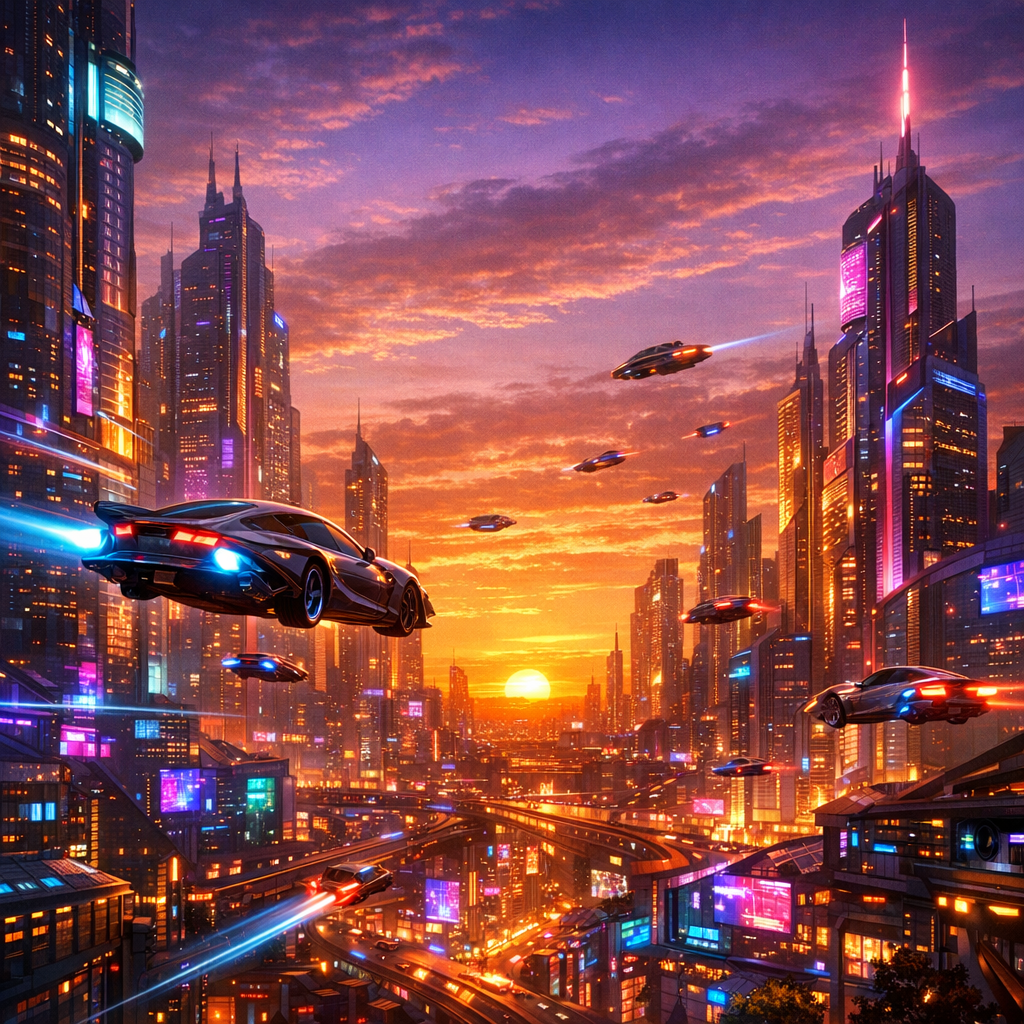

In [53]:
base64 = result.content_blocks[0]["base64"]

from PIL import Image
from io import BytesIO
import base64 as b64

image_data = b64.b64decode(base64)
image = Image.open(BytesIO(image_data))
image.show()


### Example: Using MCP Servers

In [29]:
from langchain_azure_ai.tools.builtin import McpTool

model_with_mcp = model.bind_tools([McpTool(
    server_label="api-specs",
    server_url="https://gitmcp.io/Azure/azure-rest-api-specs",
    require_approval="never"
)])

/tmp/ipykernel_16207/4142098702.py:3: ExperimentalWarning: McpTool is currently in preview and is subject to change. This preview is provided without a service-level agreement, and we don't recommend it for production workloads. Certain features might not be supported or might have constrained capabilities. For more information, see https://azure.microsoft.com/support/legal/preview-supplemental-terms
  model_with_mcp = model.bind_tools([McpTool(


In [ ]:
result = model_with_mcp.invoke("What APIs are available for Azure Cosmos DB?")

In [32]:
result.content[-1]

{'type': 'text',
 'text': "Azure Cosmos DB offers several APIs for interacting with its globally distributed, multi-model database platform. The main APIs available for Cosmos DB are:\n\n### 1. **SQL API**\n- **Purpose:** For working with JSON documents using SQL-like queries.\n- **Use case:** Core API for most Cosmos DB usage scenarios.\n\n### 2. **MongoDB API**\n- **Purpose:** Provides wire protocol compatibility with MongoDB.\n- **Use case:** You can use existing MongoDB drivers and tools with Cosmos DB, making it easy to migrate applications from MongoDB to Cosmos DB.\n\n### 3. **Cassandra API**\n- **Purpose:** Implements the Apache Cassandra wire protocol.\n- **Use case:** Allows the use of Cassandra SDKs and tools to work with Cosmos DB.\n\n### 4. **Gremlin (Graph) API**\n- **Purpose:** For working with graph data using the Gremlin query language.\n- **Use case:** Ideal for graph-based scenarios such as social networks or recommendation engines.\n\n### 5. **Table (Azure Table Sto

### Example: Using code interpreter tool

Define your tools:

In [9]:
from langchain_azure_ai.tools.builtin import CodeInterpreterTool

model_with_code_interpreter = model.bind_tools([CodeInterpreterTool()])

/tmp/ipykernel_16207/3289777909.py:3: ExperimentalWarning: CodeInterpreterTool is currently in preview and is subject to change. This preview is provided without a service-level agreement, and we don't recommend it for production workloads. Certain features might not be supported or might have constrained capabilities. For more information, see https://azure.microsoft.com/support/legal/preview-supplemental-terms
  model_with_code_interpreter = model.bind_tools([CodeInterpreterTool()])


Invoke the model:

In [10]:
result = model_with_code_interpreter.invoke("Write a Python function that returns the first 10 Fibonacci numbers, and execute it.")
print(result.content[-1]["text"])

The first 10 Fibonacci numbers are:
\[ 0, 1, 1, 2, 3, 5, 8, 13, 21, 34 \]


### Example: Using file search tool

Let's create a sample file to do the search:

In [2]:
%%writefile product_info.md

# Contoso Product Information

## The widget
- Description: A high-quality widget that is perfect for all your widget needs.
- Price: $19.99

## The gadget
- Description: An advanced gadget that offers exceptional performance and reliability.
- Price: $49.99

Overwriting product_info.md


In [ ]:
import os
from azure.ai.projects import AIProjectClient
from azure.identity import DefaultAzureCredential

# Create clients to call Foundry API
project = AIProjectClient(
    endpoint=os.environ["AZURE_AI_PROJECT_ENDPOINT"],
    credential=DefaultAzureCredential(),
)
openai = project.get_openai_client()

# Create vector store and upload file
vector_store = openai.vector_stores.create(name="ProductInfoStore")
vector_store_id = vector_store.id

with open("product_info.md", "rb") as file_handle:
    vector_store_file = openai.vector_stores.files.upload_and_poll(
        vector_store_id=vector_store.id,
        file=file_handle,
    )


Initialize the model with tools:

In [5]:
model_with_tools = model.bind_tools([FileSearchTool(vector_store_ids=[vector_store.id])])

/tmp/ipykernel_16207/2821167543.py:6: ExperimentalWarning: FileSearchTool is currently in preview and is subject to change. This preview is provided without a service-level agreement, and we don't recommend it for production workloads. Certain features might not be supported or might have constrained capabilities. For more information, see https://azure.microsoft.com/support/legal/preview-supplemental-terms
  model_with_tools = model.bind_tools([FileSearchTool(vector_store_ids=[vector_store.id])])


Call the model:

In [7]:
results = model_with_tools.invoke("Tell me about Contoso products")
print("Answer:", results.content[-1]["text"])
print("Annotations:", results.content[-1]["annotations"])

Answer: Contoso offers the following products:

1. **The widget**
   - Description: A high-quality widget that is perfect for all your widget needs.
   - Price: $19.99

2. **The gadget**
   - Description: An advanced gadget that offers exceptional performance and reliability.
   - Price: $49.99

These products are part of Contoso's main offerings as detailed in their product information documentation.
Annotations: [{'file_id': 'assistant-MvU5SEqUcUBumoLUV5BXxn', 'filename': 'product_info.md', 'type': 'file_citation', 'file_index': 395}]
